# ANN Model for CMAPSS FD001

This notebook trains an artificial neural network regressor to predict remaining useful life (RUL) for the CMAPSS jet engine dataset using the same overall workflow as the linear regression and random forest notebooks.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [28]:
DATASET = "FD001"
RANDOM_STATE = 42
MAX_RUL = 125  # Set to None if you do not want to cap the target.

index_cols = ["engine_id", "cycle"]
setting_cols = [f"setting_{i}" for i in range(1, 4)]
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]
columns = index_cols + setting_cols + sensor_cols

train_path = f"CMAPSSData/train_{DATASET}.txt"
test_path = f"CMAPSSData/test_{DATASET}.txt"
rul_path = f"CMAPSSData/RUL_{DATASET}.txt"

train_df = pd.read_csv(train_path, sep=r"\s+", header=None)
test_df = pd.read_csv(test_path, sep=r"\s+", header=None)
test_rul = pd.read_csv(rul_path, sep=r"\s+", header=None)

train_df.columns = columns
test_df.columns = columns
test_rul.columns = ["true_rul"]
test_rul["engine_id"] = np.arange(1, len(test_rul) + 1)

train_df = train_df.sort_values(["engine_id", "cycle"]).reset_index(drop=True)
test_df = test_df.sort_values(["engine_id", "cycle"]).reset_index(drop=True)

max_cycle_by_engine = train_df.groupby("engine_id")["cycle"].transform("max")
train_df["RUL"] = max_cycle_by_engine - train_df["cycle"]

if MAX_RUL is not None:
    train_df["RUL"] = train_df["RUL"].clip(upper=MAX_RUL)

candidate_features = [c for c in train_df.columns if c not in ["engine_id", "RUL"]]

print(f"Training rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")
print(f"Number of engines in training set: {train_df['engine_id'].nunique()}")
print(f"Number of engines in test set: {test_df['engine_id'].nunique()}")
print(f"Candidate features before filtering ({len(candidate_features)}): {candidate_features}")

Training rows: 20,631
Test rows: 13,096
Number of engines in training set: 100
Number of engines in test set: 100
Candidate features before filtering (25): ['cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [29]:
train_df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,125


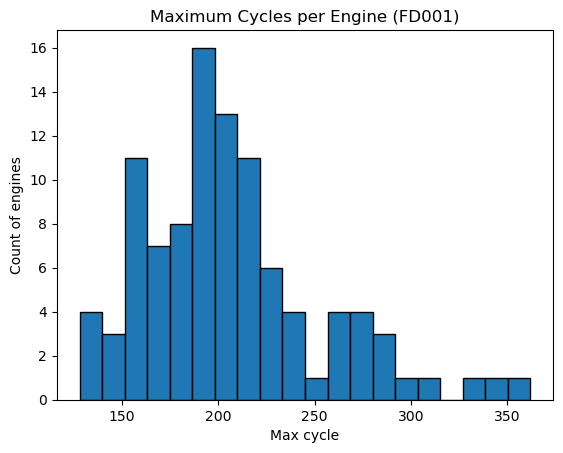

In [30]:
cycles = train_df.groupby("engine_id")["cycle"].max()
cycles.plot(kind="hist", bins=20, edgecolor="black")
plt.title(f"Maximum Cycles per Engine ({DATASET})")
plt.xlabel("Max cycle")
plt.ylabel("Count of engines")
plt.show()

In [31]:
engine_ids = train_df["engine_id"].unique()
train_engine_ids, val_engine_ids = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=RANDOM_STATE
)

train_split = train_df[train_df["engine_id"].isin(train_engine_ids)].copy()
val_split = train_df[train_df["engine_id"].isin(val_engine_ids)].copy()

constant_features = [c for c in candidate_features if train_split[c].nunique() <= 1]
feature_cols = [c for c in candidate_features if c not in constant_features]

print(f"Training engines: {len(train_engine_ids)}")
print(f"Validation engines: {len(val_engine_ids)}")
print(f"Dropped constant features: {constant_features}")
print(f"Features used ({len(feature_cols)}): {feature_cols}")

X_train = train_split[feature_cols]
y_train = train_split["RUL"]
X_val = val_split[feature_cols]
y_val = val_split["RUL"]

ann_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=256,
        learning_rate_init=1e-3,
        max_iter=400,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20,
        random_state=RANDOM_STATE
    ))
])

ann_model.fit(X_train, y_train)
val_pred = ann_model.predict(X_val)

val_rmse = float(np.sqrt(mean_squared_error(y_val, val_pred)))
val_mae = float(mean_absolute_error(y_val, val_pred))
val_r2 = float(r2_score(y_val, val_pred))

validation_metrics = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R^2"],
    "ANN": [val_rmse, val_mae, val_r2]
})

display(validation_metrics)

print(f"Validation RMSE: {val_rmse:.3f}")
print(f"Validation MAE: {val_mae:.3f}")
print(f"Validation R^2: {val_r2:.3f}")

Training engines: 80
Validation engines: 20
Dropped constant features: ['setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Features used (18): ['cycle', 'setting_1', 'setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


,Metric,ANN
0,RMSE,15.164304
1,MAE,10.588610
2,R^2,0.867856


Validation RMSE: 15.164
Validation MAE: 10.589
Validation R^2: 0.868


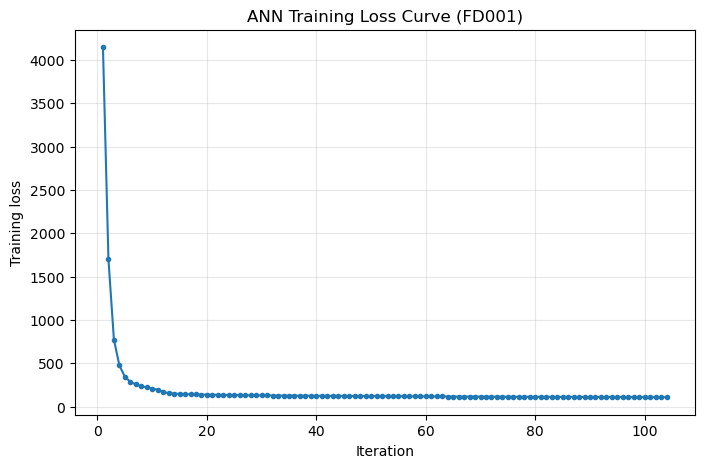

Training stopped after 104 iterations.


In [32]:
loss_curve = ann_model.named_steps["mlp"].loss_curve_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(loss_curve) + 1), loss_curve, marker="o", markersize=3)
plt.xlabel("Iteration")
plt.ylabel("Training loss")
plt.title(f"ANN Training Loss Curve ({DATASET})")
plt.grid(alpha=0.3)
plt.show()

print(f"Training stopped after {ann_model.named_steps['mlp'].n_iter_} iterations.")

In [33]:
test_last = test_df.groupby("engine_id").tail(1).copy()
test_last = test_last.merge(test_rul, on="engine_id", how="left")

if MAX_RUL is not None:
    test_last["true_rul"] = test_last["true_rul"].clip(upper=MAX_RUL)

test_pred = ann_model.predict(test_last[feature_cols])
test_rmse = float(np.sqrt(mean_squared_error(test_last["true_rul"], test_pred)))
test_mae = float(mean_absolute_error(test_last["true_rul"], test_pred))
test_r2 = float(r2_score(test_last["true_rul"], test_pred))

test_metrics = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R^2"],
    "ANN": [test_rmse, test_mae, test_r2]
})

display(test_metrics)

print(f"Test RMSE: {test_rmse:.3f}")
print(f"Test MAE: {test_mae:.3f}")
print(f"Test R^2: {test_r2:.3f}")

results_df = pd.DataFrame({
    "engine_id": test_last["engine_id"],
    "actual_rul": test_last["true_rul"],
    "predicted_rul": np.round(test_pred, 2),
    "error": np.round(test_pred - test_last["true_rul"], 2)
}).sort_values("engine_id")

results_df.head(10)

,Metric,ANN
0,RMSE,17.971280
1,MAE,13.258299
2,R^2,0.798883


Test RMSE: 17.971
Test MAE: 13.258
Test R^2: 0.799


,engine_id,actual_rul,predicted_rul,error
0,1,112,119.32,7.32
1,2,98,120.17,22.17
2,3,69,69.27,0.27
3,4,82,82.61,0.61
4,5,91,98.97,7.97
5,6,93,88.65,-4.35
6,7,91,105.31,14.31
7,8,95,67.18,-27.82
8,9,111,117.32,6.32
9,10,96,99.07,3.07


In [34]:
mean_signed_error = float(results_df["error"].mean())
median_signed_error = float(results_df["error"].median())
over_predictions = int((results_df["error"] > 0).sum())
under_predictions = int((results_df["error"] < 0).sum())
exact_predictions = int((results_df["error"] == 0).sum())

bias_summary = pd.DataFrame({
    "Metric": [
        "Mean signed error",
        "Median signed error",
        "Over-predictions",
        "Under-predictions",
        "Exact predictions"
    ],
    "Value": [
        mean_signed_error,
        median_signed_error,
        over_predictions,
        under_predictions,
        exact_predictions
    ]
})

display(bias_summary)

if mean_signed_error > 0:
    print(f"On average, the model over-predicts by {mean_signed_error:.2f} cycles.")
elif mean_signed_error < 0:
    print(f"On average, the model under-predicts by {abs(mean_signed_error):.2f} cycles.")
else:
    print("On average, the model is unbiased in signed error.")

,Metric,Value
0,Mean signed error,-1.0873
1,Median signed error,0.4400
2,Over-predictions,51.0000
3,Under-predictions,49.0000
4,Exact predictions,0.0000


On average, the model under-predicts by 1.09 cycles.


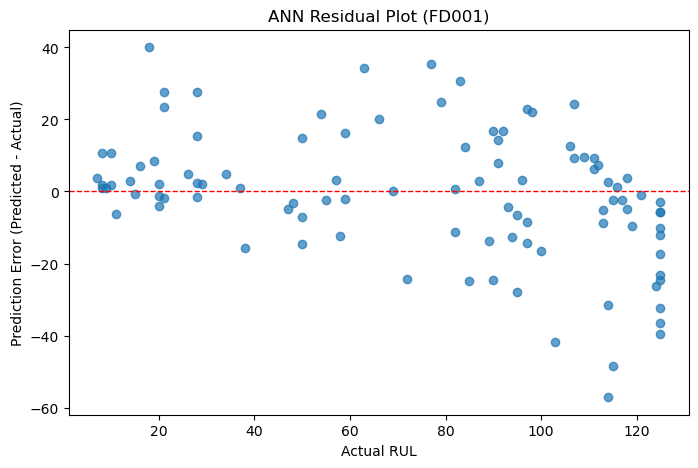

In [35]:
plt.figure(figsize=(8, 5))
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.scatter(results_df["actual_rul"], results_df["error"], alpha=0.7)
plt.xlabel("Actual RUL")
plt.ylabel("Prediction Error (Predicted - Actual)")
plt.title(f"ANN Residual Plot ({DATASET})")
plt.show()

cycle        10.996464
sensor_14     2.706165
sensor_9      2.648528
sensor_11     1.884893
sensor_12     1.528041
sensor_13     0.946467
sensor_8      0.833045
sensor_15     0.731486
sensor_4      0.660147
sensor_7      0.627120
dtype: float64

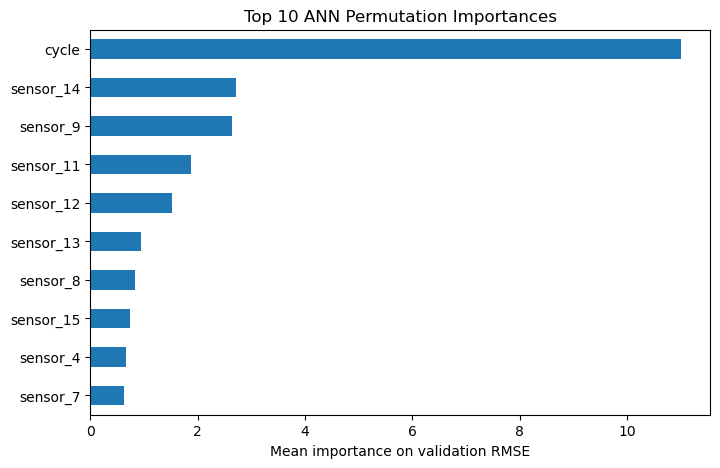

In [36]:
perm_result = permutation_importance(
    ann_model,
    X_val,
    y_val,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error"
)

feature_importance = pd.Series(
    perm_result.importances_mean,
    index=feature_cols
).sort_values(ascending=False)

display(feature_importance.head(10))

feature_importance.head(10).sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Top 10 ANN Permutation Importances")
plt.xlabel("Mean importance on validation RMSE")
plt.show()

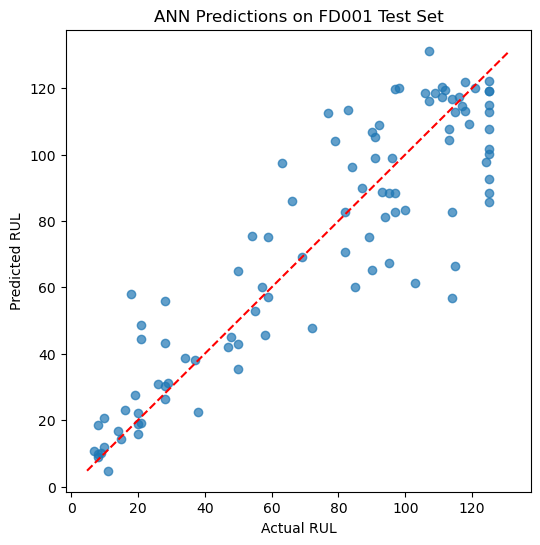

In [37]:
plt.figure(figsize=(6, 6))
plt.scatter(test_last["true_rul"], test_pred, alpha=0.7)
min_val = min(test_last["true_rul"].min(), test_pred.min())
max_val = max(test_last["true_rul"].max(), test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--")
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title(f"ANN Predictions on {DATASET} Test Set")
plt.show()

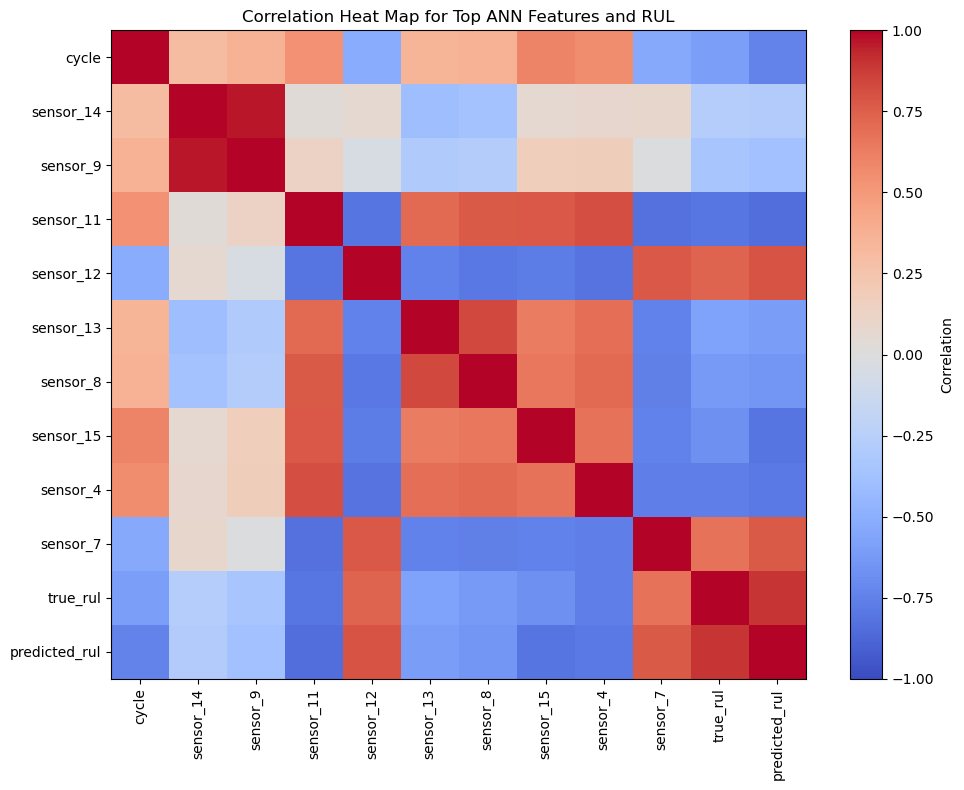

In [38]:
top_heatmap_features = feature_importance.head(10).index.tolist()
heatmap_df = test_last[top_heatmap_features].copy()
heatmap_df["true_rul"] = test_last["true_rul"].values
heatmap_df["predicted_rul"] = test_pred
corr_matrix = heatmap_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Heat Map for Top ANN Features and RUL")
plt.tight_layout()
plt.show()

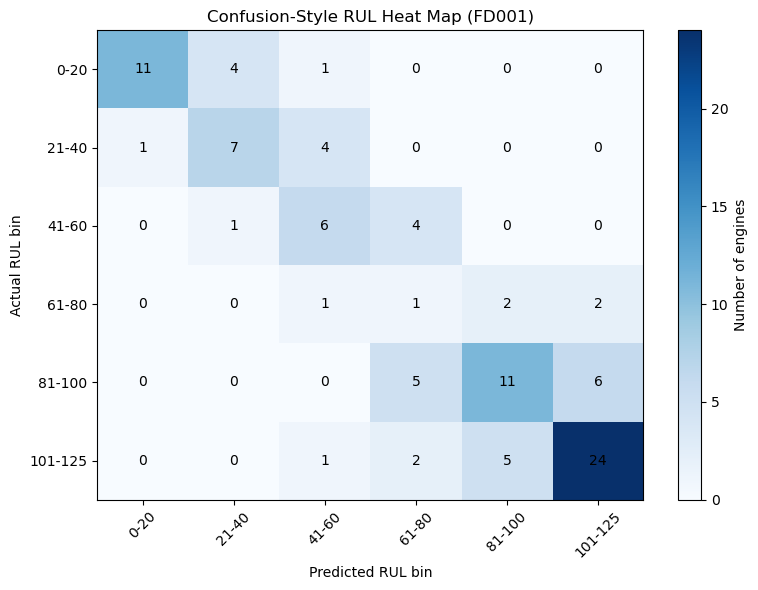

predicted_bin,0-20,21-40,41-60,61-80,81-100,101-125
actual_bin,,,,,,
0-20,11,4,1,0,0,0
21-40,1,7,4,0,0,0
41-60,0,1,6,4,0,0
61-80,0,0,1,1,2,2
81-100,0,0,0,5,11,6
101-125,0,0,1,2,5,24


In [39]:
bin_edges = [0, 20, 40, 60, 80, 100, 125]
bin_labels = ["0-20", "21-40", "41-60", "61-80", "81-100", "101-125"]

confusion_df = results_df.copy()
confusion_df["actual_bin"] = pd.cut(
    confusion_df["actual_rul"],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True
)
confusion_df["predicted_bin"] = pd.cut(
    confusion_df["predicted_rul"],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True
)

confusion_matrix = pd.crosstab(
    confusion_df["actual_bin"],
    confusion_df["predicted_bin"],
    dropna=False
)

plt.figure(figsize=(8, 6))
plt.imshow(confusion_matrix, cmap="Blues", aspect="auto")
plt.colorbar(label="Number of engines")
plt.xticks(range(len(confusion_matrix.columns)), confusion_matrix.columns, rotation=45)
plt.yticks(range(len(confusion_matrix.index)), confusion_matrix.index)
plt.xlabel("Predicted RUL bin")
plt.ylabel("Actual RUL bin")
plt.title(f"Confusion-Style RUL Heat Map ({DATASET})")

for i in range(confusion_matrix.shape[0]):
    for j in range(confusion_matrix.shape[1]):
        plt.text(j, i, confusion_matrix.iloc[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

confusion_matrix